In [ ]:
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["font.family"] = "Nirmala UI"


train_json_path = fr"D:\AI-Video-Captioning-In-Nepali-Using-Transformers\msvd_dataset_std_1200_100_670_split\train.json"
val_json_path = fr"D:\AI-Video-Captioning-In-Nepali-Using-Transformers\msvd_dataset_std_1200_100_670_split\val.json"




def load_captions(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    captions = []
    for item in data:
        if "nepali_captions" in item:
            captions.extend(item["nepali_captions"])
    return captions

train_captions = load_captions(train_json_path)
val_captions = load_captions(val_json_path)

all_captions = train_captions + val_captions

print("Train captions:", len(train_captions))
print("Val captions:", len(val_captions))
print("Total captions:", len(all_captions))

all_words = []
for caption in all_captions:
    caption = str(caption).strip()
    caption = re.sub(r"[।,!?\"'“”‘’()\-]", "", caption)
    words = caption.split()
    all_words.extend(words)

word_counts = Counter(all_words)
top_10_words = word_counts.most_common(10)

print("\nTop 10 most frequent words:")
for word, count in top_10_words:
    print(f"{word}: {count}")

Train captions: 49121
Val captions: 4191
Total captions: 53312

Top 10 most frequent words:
छ: 18761
एक: 15749
एउटा: 11106
मानिस: 8441
महिला: 6571
छन्: 6325
एउटी: 6240
छिन्: 5124
काट्दै: 3427
र: 3329


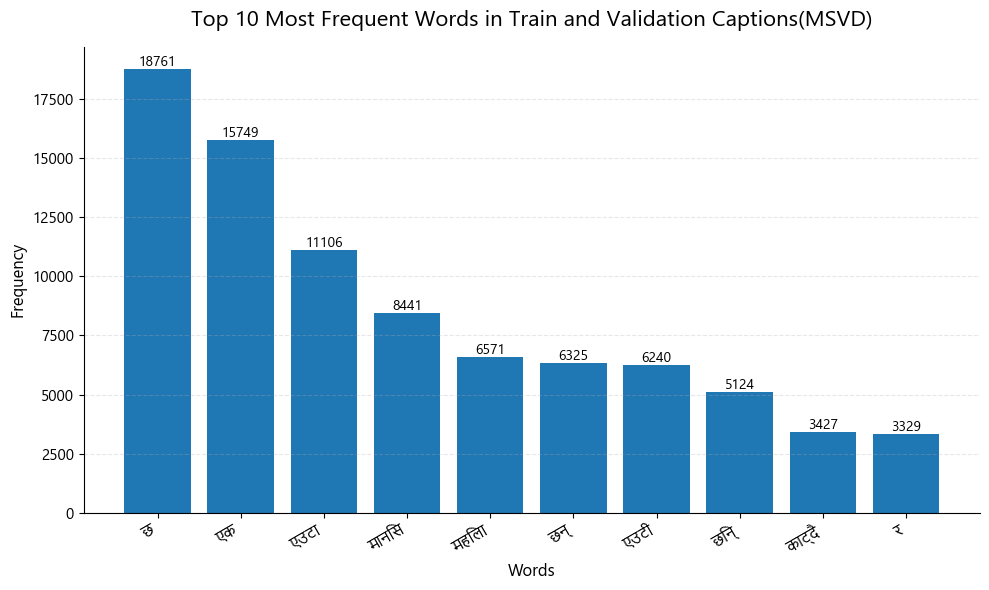

In [3]:
words = [word for word, count in top_10_words]
counts = [count for word, count in top_10_words]

plt.figure(figsize=(10, 6))
bars = plt.bar(words, counts)

plt.title("Top 10 Most Frequent Words in Train and Validation Captions(MSVD)", fontsize=16, pad=15)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [4]:
def load_captions(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    captions = []
    for item in data:
        captions.extend(item.get("nepali_captions", []))
    return captions

train_captions = load_captions(train_json_path)
val_captions = load_captions(val_json_path)
all_captions = train_captions + val_captions

caption_lengths = [len(str(caption).split()) for caption in all_captions]


min_len = min(caption_lengths)
max_len = max(caption_lengths)

shortest_captions = [c for c in all_captions if len(str(c).split()) == min_len]
longest_captions = [c for c in all_captions if len(str(c).split()) == max_len]


print("Total captions:", len(all_captions))
print("Minimum caption length:", min(caption_lengths))
print("Maximum caption length:", max(caption_lengths))
print("Average caption length:", sum(caption_lengths) / len(caption_lengths))


print("\nExample shortest caption:")
print(shortest_captions[0])

print("\nExample longest caption:")
print(longest_captions[0])

Total captions: 53312
Minimum caption length: 1
Maximum caption length: 40
Average caption length: 5.633272058823529

Example shortest caption:
झोला

Example longest caption:
मैले यो चलचित्र लगभग 20 वर्षमा हेरेको थिइनँ मेरो बाल्यकालको सबैभन्दा पुरानो सम्झनाहरू मध्ये एक यो चलचित्र हेरिरहेको थियो जब मेरी आमाले 1990 मा यो मेरो लागि भाडामा लिनुभयो मलाई यो वास्तवमै दुखद चलचित्र हो तर झूट नबोल्ने सम्झना छ।


In [ ]:
# Extract all captions (flattened)
def extract_captions(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    captions = []

    for item in data:
        if "nepali_captions" in item:
            captions.extend(item["nepali_captions"])  # flatten list of captions

    return captions


# Build vocabulary
def build_vocab(captions):
    vocab = set()

    for cap in captions:
        words = cap.split()   # basic tokenization
        vocab.update(words)

    return vocab


# Load captions
train_caps = extract_captions(train_json_path)
val_caps = extract_captions(val_json_path)

all_caps = train_caps + val_caps

# Compute vocabulary
vocab = build_vocab(all_caps)

# Results
print(f"Total captions: {len(all_caps)}")
print(f"Total vocabulary size: {len(vocab)}")

# Print some words
print("\nSample words from vocab:")
print(list(vocab)[:50])

Total captions: 53312
Total vocabulary size: 14133

Sample words from vocab:
['बन्डलले', 'चाहन्थे', 'tu', 'बिगारिरहेका', '२०', 'न्यूज्याङ्कर', 'सीडीको', '१२', 'मान्छेले', 'खाडल', 'नभई', 'कटरमा', 'जिमको', 'खोजिरहेका', 'पारिएको', 'बोसोका', 'जादूगर', 'बोलाउँछ', 'पेरोटले', 'कल्याण', 'ठोकेका', 'स्कुटरमा', 'देखाउँदैछन्', 'सुशीको', 'तेलुगु', 'फ्रिस्टाइल', 'असामान्य', 'सिकाइरहेकी', '\u200b\u200bचालहरू', 'जुगल', 'दलिया', 'सीएनसी', 'जस्तो', 'जिज्ञासु', 'लगाइदिइन्', 'पार्ट्स', 'केटाकेटीले', 'बास्केटबलहरू', 'गेरे', 'बास', 'फुजी', 'थ्रीटायर', 'दैनिक', 'डुबाउँदैछ', 'हेलिकप्टरले', 'क्यामेराको', 'कुकिंगले', 'आउट', 'ट्रेसरहरूको', 'लडाकुले']
